# Customer Churn Prediction using Deep Learning
**Genesis Adam D. Mendoza**

### Overview

This project uses a neural network model to predict whether a customer is likely to cancel their subscription based on a dataset from Kaggle [(link)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn/). This is a classic example of binary classification and is highly significant for formulating customer retention strategies.

The project demonstrates the application of deep learning techniques to structured business data using TensorFlow/Keras.

### Dataset description

**Rows**: 7,043 customers\
**Target**: `Churn` – whether the customer left the company in the last month\
**Features**:
- *Demographics*: Gender, senior citizenship, partner, dependents
- *Services*: Phone, internet, online backup, tech support, streaming
- *Account Info*: Contract type, billing method, tenure, charges

## I. Setting up

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import os

from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, recall_score, f1_score, ConfusionMatrixDisplay, precision_recall_curve, PrecisionRecallDisplay

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTENC

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras.metrics import AUC
import tensorflow_addons as tfa 

plt.rcParams['text.usetex'] = True
plt.rcParams.update({'font.size': 15})

C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
C:\Users\PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\tensorflow_addons\utils\ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.12.0 and strictly below 2.15.0 (nightly versions are not supported). 
 The versions of TensorFlow you

We want to maximize the reproducibility of our results by setting a seed.

In [2]:
def set_seed(seed):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(299792458)

Initiate the data set.

In [3]:
ibm_churn = pd.read_csv('..//data//ibm_churn_dataset.csv')
ibm_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
ibm_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


It is weird to have the `TotalCharges` as a non-numeric column. We change it accordingly.

In [5]:
ibm_churn['TotalCharges'] = pd.to_numeric(ibm_churn['TotalCharges'], errors='coerce')

In [6]:
ibm_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Split the data set into the training, validation, and test set. We will use the test set for the final reporting.

In [7]:
ibm_churn_cop = ibm_churn.copy()
ibm_churn_cop.set_index('customerID', inplace=True)
ibm_targ = ['Churn']
ibm_feat = [col for col in ibm_churn_cop.columns if col not in ibm_targ]
targ = ibm_churn_cop[ibm_targ]
feats = ibm_churn_cop[ibm_feat]

x_tv, x_test, y_tv, y_test = train_test_split(feats, targ, test_size=0.2, random_state=42)
x_train, x_valid, y_train, y_valid = train_test_split(x_tv, y_tv, test_size=0.25, random_state=42)

Check if there are null columns and the amount of null values.

In [8]:
null_cols = [col for col in feats.columns if feats[col].isnull().any()]
null_count = ibm_churn_cop[null_cols].isnull().sum()
null_count

TotalCharges    11
dtype: int64

Lay out the information for `NaN` total charges.

In [9]:
ibm_churn_cop[ibm_churn_cop['TotalCharges'].isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No


It is logical that there are no TotalCharges if the Tenure is 0. Instead of `NaN`, we fill it up with $0$. We determine numerical and categorical columns so they can be processed accordingly. 

In [10]:
num_cols = [col for col in ibm_feat if feats[col].dtype in ['int64', 'float64']]
cat_cols = [col for col in ibm_feat if feats[col].dtype in ['object']]
cat_feat = [i for i, col in enumerate(ibm_feat) if col in cat_cols] #indices of categorical columns

Transform the numerical columns by rescaling it in such a way that the mean of the column is $0$ and the standard deviation is $1$. If we are to use neural networks to train using gradient descent, then it is imperative to put each feature in an equal footing, rather than giving one more importance because of its scale. We use the `StandardScaler()` for this. For the categorical columns, we simply use `OneHotEncoder`. We ensure that the arrays are dense, so we use `FunctionTransformer`.

In [11]:
num_transformer = Pipeline(steps = [('imputer', SimpleImputer(strategy = 'constant', fill_value = 0)), ('scaler', StandardScaler())])
cat_transformer = OneHotEncoder(handle_unknown = 'ignore')
preprocess = ColumnTransformer(transformers = [('num', num_transformer, num_cols), ('cat', cat_transformer, cat_cols)])
pipeline = Pipeline(steps = [('preprocess', preprocess), 
                             ('to_array', FunctionTransformer(lambda x: x.toarray() if hasattr(x, 'to_array') else x))
                             ])

## II. Preliminary model

We will construct a baseline model with binary accuracy as a metric. This is not to say that binary accuracy is the best metric to use in this case, as we will discuss later. For now, our focus will be the neural network architecture. To determine the architecture, we will follow Heaton's prescription for layer and neuron number. For the layers, we have

| Number of Hidden Layers | Result                                                                                                                                           |
|-------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------|
| None                    | Only capable of representing linear separable functions or decisions.                                                                           |
| 1                       | Can approximate arbitrarily with any functions which contains a continuous mapping from one finite space to another.                           |
| 2                       | Represent an arbitrary decision boundary to arbitrary accuracy with rational activation functions and can approximate any smooth mapping to any accuracy. |

The rule-of-thumb methods for determining the correct number of neurons are as follows:

- The number of hidden neurons should be between the size of the input layer and the 
size of the output layer.
- The number of hidden neurons should be 2/3 of the input layer size, plus the size of 
the output layer.
- The number of hidden neurons should be less than twice the input layer size.

In our case, after preprocessing, the input shape is 45 and the output shape is 1. The first criteria puts the number of hidden neurons to $(1,45)$. The second criteria tells us that it must be $\~31$. The final criteria is less stringent, putting us to $<90$. We follow the second criteria and decide post-hoc whether the best architecture is `32`, `16 → 16`, `16 → 8 → 8`, or `8 → 8 → 8 → 8`. Rule of thumb tells us that one hidden layer, `32`, is enough, and we can verify that larger number of layers for this particular model lead to underfitting. I have to emphasize that optimal architecture is best found via experimentation. The rule-of-thumbs are simply heuristics. Moving forward, we add a dropout layer to prevent the network from learning the patterns of the training data too much (overfitting). As an additional layer of protection from overfitting, we also incorporate the `EarlyStopping` function that terminates learning whenever the monitored metric does not improve given a certain amount of epochs. By default, the monitored metric is the validation loss.

In [12]:
x_train_prep = pipeline.fit_transform(x_train)
x_valid_prep = pipeline.transform(x_valid)
x_test_prep = pipeline.transform(x_test)
y_train_prep = y_train['Churn'].map({'No':0, 'Yes':1}).values # convert y_values from No and Yes to 0 and 1 forcibly
y_valid_prep = y_valid['Churn'].map({'No':0, 'Yes':1}).values
y_test_prep = y_test['Churn'].map({'No':0, 'Yes':1}).values

early_stopping = EarlyStopping(
    min_delta = 0.001,
    patience = 10,
    restore_best_weights = True
)

model = keras.Sequential([
    layers.Dense(32, activation = 'relu', input_shape = [x_train_prep.shape[1]]),
    layers.Dropout(rate = 0.3),
    layers.BatchNormalization(),
    layers.Dense(1, activation = 'sigmoid')
])

model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['binary_accuracy']
)

fit = model.fit(x_train_prep, y_train_prep,
                validation_data = (x_valid_prep, y_valid_prep),
                batch_size = 32,
                epochs = 50,
                callbacks = [early_stopping],
                verbose = 1)



Epoch 1/50


133/133 [==============================] - 1s 3ms/step - loss: 0.6199 - binary_accuracy: 0.6656 - val_loss: 0.4589 - val_binary_accuracy: 0.7857
Epoch 2/50
133/133 [==============================] - 0s 2ms/step - loss: 0.4918 - binary_accuracy: 0.7619 - val_loss: 0.4429 - val_binary_accuracy: 0.8006
Epoch 3/50
133/133 [==============================] - 0s 2ms/step - loss: 0.4670 - binary_accuracy: 0.7818 - val_loss: 0.4354 - val_binary_accuracy: 0.7970
Epoch 4/50
133/133 [==============================] - 0s 2ms/step - loss: 0.4526 - binary_accuracy: 0.7768 - val_loss: 0.4390 - val_binary_accuracy: 0.7970
Epoch 5/50
133/133 [==============================] - 0s 2ms/step - loss: 0.4462 - binary_accuracy: 0.7858 - val_loss: 0.4359 - val_binary_accuracy: 0.7949
Epoch 6/50
133/133 [==============================] - 0s 2ms/step - loss: 0.4365 - binary_accuracy: 0.7948 - val_loss: 0.4315 - val_binary_accuracy: 0.7984
Epoch 7/50
133/133 [==============================] - 0s 2ms

We plot the loss curve to determine if the model is overfitting or underfitting.

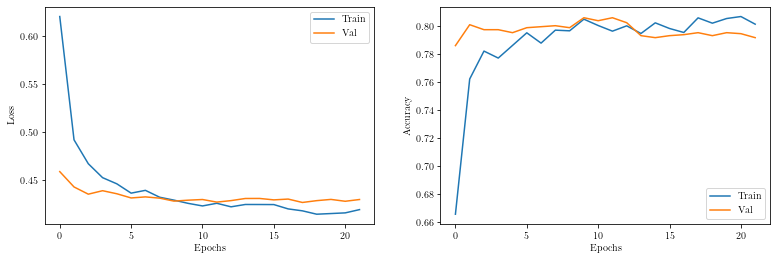

In [13]:
plt.figure(figsize=(13,4))

plt.subplot(1,2,1)
plt.plot(fit.history['loss'], label='$\mathrm{Train}$')
plt.plot(fit.history['val_loss'], label='$\mathrm{Val}$')
plt.xlabel('$\mathrm{Epochs}$')
plt.ylabel('$\mathrm{Loss}$')
plt.legend()

plt.subplot(1,2,2)
plt.plot(fit.history['binary_accuracy'], label='$\mathrm{Train}$')
plt.plot(fit.history['val_binary_accuracy'], label='$\mathrm{Val}$')
plt.xlabel('$\mathrm{Epochs}$')
plt.ylabel('$\mathrm{Accuracy}$')
plt.legend()

plt.show()

The loss curve for the validation set stabilizes at Epoch 5, implying that the model extracts the information from data well given the architecture. 

In [14]:
y_pred = model.predict(x_valid_prep)
y_pred = (y_pred > 0.5).astype(int)
print(classification_report(y_valid_prep, y_pred))

45/45 [==============================] - 0s 1ms/step
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1030
           1       0.69      0.50      0.58       379

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409



The precision column tells us that out of all the predicted $0$ or $1$, how many were actually true. On the other hand, the recall column tells us that out of all the true $0$ or $1$, how many were predicted correctly. We need to focus more on the `Yes` label, which corresponds to the churners. We can see that the model can only catch half of the true churners. Half is a significant loss for the company. 

In [15]:
y_train['Churn'].value_counts(normalize=True)

Churn
No     0.735621
Yes    0.264379
Name: proportion, dtype: float64

The failure to detect churning customers well can be attributed to the imbalance where churning customers are in the minority compared to the non-churning customers. The model seems to be cozy with identifying non-churning customers. The first course of action is to synthetically increase the number of the minority class, in that way we can somehow level the playing field, through the Synthetic Minority Oversampling Technique or SMOTE, and redo the training.

## III. SMOTE

We want to increase the number of the minority class (churners), but not too much. The synthetic data is only based on the available churn data, and we don't want the model to rely heavily on them, making it hard for the model to generalize to unseen data. We will then set the number of churners in the training data to $70\%$ of the non-churners. We need to be careful with using synthetic data. We only use untouched data for validation.

In [16]:
x_smote, y_smote = SMOTENC(sampling_strategy = 0.7, categorical_features = cat_feat).fit_resample(x_train_prep, y_train_prep)

early_stopping = EarlyStopping(
    min_delta = 0.001,
    patience = 10,
    restore_best_weights = True
)

model = keras.Sequential([
    layers.Dense(32, activation = 'relu', input_shape = [x_train_prep.shape[1]]),
    layers.Dropout(rate = 0.3),
    layers.BatchNormalization(),
    layers.Dense(1, activation = 'sigmoid')
])

model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['binary_accuracy']
)

fit = model.fit(x_smote, y_smote,
                validation_data = (x_valid_prep, y_valid_prep),
                batch_size = 32,
                epochs = 50,
                callbacks = [early_stopping],
                verbose = 1)

Epoch 1/50
166/166 [==============================] - 1s 3ms/step - loss: 0.5989 - binary_accuracy: 0.6973 - val_loss: 0.4753 - val_binary_accuracy: 0.7729
Epoch 2/50
166/166 [==============================] - 0s 2ms/step - loss: 0.5121 - binary_accuracy: 0.7469 - val_loss: 0.4490 - val_binary_accuracy: 0.7857
Epoch 3/50
166/166 [==============================] - 0s 2ms/step - loss: 0.4976 - binary_accuracy: 0.7588 - val_loss: 0.4552 - val_binary_accuracy: 0.7842
Epoch 4/50
166/166 [==============================] - 0s 2ms/step - loss: 0.4851 - binary_accuracy: 0.7623 - val_loss: 0.4503 - val_binary_accuracy: 0.7878
Epoch 5/50
166/166 [==============================] - 0s 2ms/step - loss: 0.4797 - binary_accuracy: 0.7657 - val_loss: 0.4501 - val_binary_accuracy: 0.7892
Epoch 6/50
166/166 [==============================] - 0s 2ms/step - loss: 0.4698 - binary_accuracy: 0.7736 - val_loss: 0.4500 - val_binary_accuracy: 0.7864
Epoch 7/50
166/166 [==============================] - 0s 2ms/ste

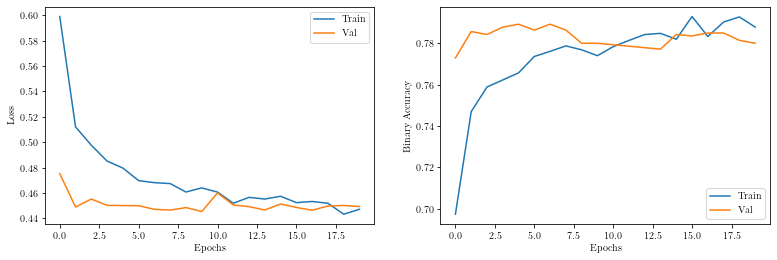

In [17]:
plt.figure(figsize=(13,4))

plt.subplot(1,2,1)
plt.plot(fit.history['loss'], label='$\mathrm{Train}$')
plt.plot(fit.history['val_loss'], label='$\mathrm{Val}$')
plt.xlabel('$\mathrm{Epochs}$')
plt.ylabel('$\mathrm{Loss}$')
plt.legend()

plt.subplot(1,2,2)
plt.plot(fit.history['binary_accuracy'], label='$\mathrm{Train}$')
plt.plot(fit.history['val_binary_accuracy'], label='$\mathrm{Val}$')
plt.xlabel('$\mathrm{Epochs}$')
plt.ylabel('$\mathrm{Binary\ Accuracy}$')
plt.legend()

plt.show()

In [18]:
y_pred = model.predict(x_valid_prep)
y_pred = (y_pred > 0.5).astype(int)
print(classification_report(y_valid_prep, y_pred))

45/45 [==============================] - 0s 1ms/step
              precision    recall  f1-score   support

           0       0.86      0.83      0.85      1030
           1       0.58      0.65      0.61       379

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



The model increased the number of churners caught by giving each class a somewhat equal representation at the expense of precision. Meaning, more non-churners are misidentified as churners and more churners are correctly identified. Despite the agressiveness in finding churners, the performance is still not enough since a third of the churners are not caught, but we know we're in the right direction. We will optimize the F1 score, being the harmonic mean between the precision and recall, of the positive class instead of the accuracy because of two things: first, we care about the churners more since they likely mean loss for the company, and second, accuracy is misleading in highly imbalanced data. For example, if there are 10 customers with 8 non-churners and 2 churners and we identified all of them as churners, it still means $80\%$ accuracy.

In [19]:
x_smote, y_smote = SMOTENC(sampling_strategy = 0.7, categorical_features = cat_feat).fit_resample(x_train_prep, y_train_prep)

early_stopping = EarlyStopping(
    monitor = 'val_f1_score',
    mode = 'max',
    min_delta = 0.001,
    patience = 10,
    restore_best_weights = True
)

model = keras.Sequential([
    layers.Dense(32, activation = 'relu', input_shape = [x_train_prep.shape[1]]),
    layers.Dropout(rate = 0.3),
    layers.BatchNormalization(),
    layers.Dense(1, activation = 'sigmoid')
])

model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = [tfa.metrics.F1Score(num_classes = 1, threshold = 0.5)]
)

fit = model.fit(x_smote, y_smote,
                validation_data = (x_valid_prep, y_valid_prep),
                batch_size = 32,
                epochs = 50,
                callbacks = [early_stopping],
                verbose = 1)

Epoch 1/50
166/166 [==============================] - 1s 3ms/step - loss: 0.5828 - f1_score: 0.6634 - val_loss: 0.4858 - val_f1_score: 0.6126
Epoch 2/50
166/166 [==============================] - 0s 2ms/step - loss: 0.5173 - f1_score: 0.6961 - val_loss: 0.4560 - val_f1_score: 0.6297
Epoch 3/50
166/166 [==============================] - 0s 2ms/step - loss: 0.4971 - f1_score: 0.7114 - val_loss: 0.4523 - val_f1_score: 0.6196
Epoch 4/50
166/166 [==============================] - 0s 2ms/step - loss: 0.4891 - f1_score: 0.7120 - val_loss: 0.4542 - val_f1_score: 0.6203
Epoch 5/50
166/166 [==============================] - 0s 2ms/step - loss: 0.4728 - f1_score: 0.7235 - val_loss: 0.4507 - val_f1_score: 0.6250
Epoch 6/50
166/166 [==============================] - 0s 2ms/step - loss: 0.4725 - f1_score: 0.7224 - val_loss: 0.4471 - val_f1_score: 0.6091
Epoch 7/50
166/166 [==============================] - 0s 2ms/step - loss: 0.4617 - f1_score: 0.7351 - val_loss: 0.4531 - val_f1_score: 0.6184
Epoch 

In addition to the loss-curve, we also want to plot the precision-recall curve, as parametrized by the threshold.

45/45 [==============================] - 0s 1ms/step


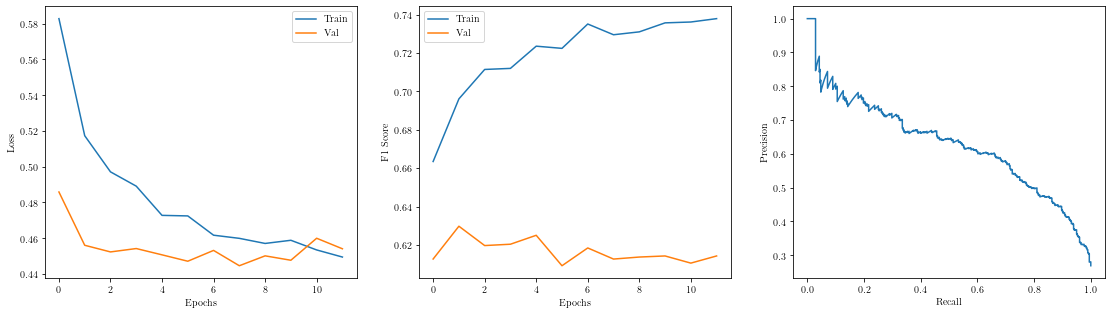

In [20]:
plt.figure(figsize=(19,5))

plt.subplot(1,3,1)
plt.plot(fit.history['loss'], label='$\mathrm{Train}$')
plt.plot(fit.history['val_loss'], label='$\mathrm{Val}$')
plt.xlabel('$\mathrm{Epochs}$')
plt.ylabel('$\mathrm{Loss}$')
plt.legend()

plt.subplot(1,3,2)
plt.plot(fit.history['f1_score'], label='$\mathrm{Train}$')
plt.plot(fit.history['val_f1_score'], label='$\mathrm{Val}$')
plt.xlabel('$\mathrm{Epochs}$')
plt.ylabel('$\mathrm{F1\ Score}$')
plt.legend()

plt.subplot(1,3,3)
y_pred = model.predict(x_valid_prep)
precision, recall, thresholds = precision_recall_curve(y_valid_prep, y_pred)
plt.plot(recall, precision)
plt.xlabel('$\mathrm{Recall}$')
plt.ylabel('$\mathrm{Precision}$')

plt.show()

There is the tradeoff between the precision and recall values for Churn. Increasing the recall value decreases the precision, and vice versa. The F1 score is the harmonic mean between these two values. If we look at the F1 score as a function of threshold, we can see that there is a maximum point.

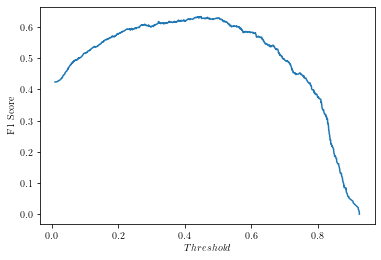

The maximum F1 Score is 0.634 given the threshold 0.449


In [ ]:
f1 = 2*precision*recall/(precision + recall)
plt.plot(np.append(thresholds, thresholds[-1]+10e-5), f1)
plt.xlabel('\mathrm{Threshold}$')
plt.ylabel('$\mathrm{F1\ Score}$')
plt.show()

thresh = thresholds[np.nanargmax(f1)]
print('The maximum F1 Score is {:.3f} given the threshold {:.3f}'.format(f1[np.nanargmax(f1)], thresh))

The maximum F1 score for a threshold of 0.449, which is 0.634, is near the maximum F1 score for a threshold of 0.5, which is 0.63.

In [22]:
y_pred = model.predict(x_valid_prep)
y_pred = (y_pred > thresh).astype(int) 
print(classification_report(y_valid_prep, y_pred))

45/45 [==============================] - 0s 803us/step
              precision    recall  f1-score   support

           0       0.88      0.81      0.85      1030
           1       0.58      0.70      0.63       379

    accuracy                           0.78      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.78      0.79      1409



There is a slight improvement in both the recall and F1 score of the churners. There is a slight decrease in precision, which was expected from the precision-recall curve.

## IV. SMOTE + Regularization

We now add L2 (ridge) regularization to the hidden layer, which penalizes large weights during training. This encourages the model to prefer simpler weight configurations, discouraging reliance on any one feature unless it meaningfully contributes to minimizing the loss. 

In [23]:
x_smote, y_smote = SMOTENC(sampling_strategy = 0.7, categorical_features = cat_feat).fit_resample(x_train_prep, y_train_prep)

early_stopping = EarlyStopping(
    monitor = 'val_f1_score',
    mode = 'max',
    min_delta = 0.001,
    patience = 10,
    restore_best_weights = True
)

model = keras.Sequential([
    layers.Dense(32, activation = 'relu', input_shape = [x_train_prep.shape[1]], kernel_regularizer = l2(0.0001)),
    layers.Dropout(rate = 0.3),
    layers.BatchNormalization(),
    layers.Dense(1, activation = 'sigmoid')
])

model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = [tfa.metrics.F1Score(num_classes = 1, threshold = 0.5)]
)

fit = model.fit(x_smote, y_smote,
                validation_data = (x_valid_prep, y_valid_prep),
                batch_size = 32,
                epochs = 50,
                callbacks = [early_stopping],
                verbose = 1)

Epoch 1/50
166/166 [==============================] - 1s 3ms/step - loss: 0.6039 - f1_score: 0.6509 - val_loss: 0.4619 - val_f1_score: 0.5946
Epoch 2/50
166/166 [==============================] - 0s 2ms/step - loss: 0.5228 - f1_score: 0.6958 - val_loss: 0.4540 - val_f1_score: 0.6119
Epoch 3/50
166/166 [==============================] - 0s 2ms/step - loss: 0.4943 - f1_score: 0.7115 - val_loss: 0.4670 - val_f1_score: 0.6060
Epoch 4/50
166/166 [==============================] - 0s 2ms/step - loss: 0.4867 - f1_score: 0.7176 - val_loss: 0.4668 - val_f1_score: 0.6116
Epoch 5/50
166/166 [==============================] - 0s 2ms/step - loss: 0.4837 - f1_score: 0.7147 - val_loss: 0.4655 - val_f1_score: 0.6026
Epoch 6/50
166/166 [==============================] - 0s 2ms/step - loss: 0.4770 - f1_score: 0.7231 - val_loss: 0.4550 - val_f1_score: 0.6067
Epoch 7/50
166/166 [==============================] - 0s 2ms/step - loss: 0.4676 - f1_score: 0.7283 - val_loss: 0.4646 - val_f1_score: 0.6063
Epoch 

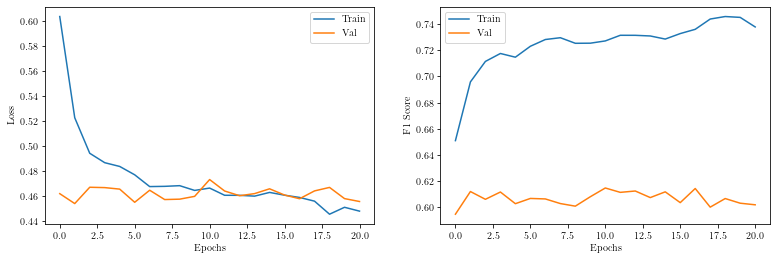

In [24]:
plt.figure(figsize=(13,4))

plt.subplot(1,2,1)
plt.plot(fit.history['loss'], label='$\mathrm{Train}$')
plt.plot(fit.history['val_loss'], label='$\mathrm{Val}$')
plt.xlabel('$\mathrm{Epochs}$')
plt.ylabel('$\mathrm{Loss}$')
plt.legend()

plt.subplot(1,2,2)
plt.plot(fit.history['f1_score'], label='$\mathrm{Train}$')
plt.plot(fit.history['val_f1_score'], label='$\mathrm{Val}$')
plt.xlabel('$\mathrm{Epochs}$')
plt.ylabel('$\mathrm{F1\ Score}$')
plt.legend()

plt.show()

In [25]:
y_pred = model.predict(x_valid_prep)
precision, recall, thresholds = precision_recall_curve(y_valid_prep, y_pred)
f1 = 2*precision*recall/(precision + recall)
thresh = thresholds[np.nanargmax(f1)]
y_pred = (y_pred > thresh).astype(int)
print(classification_report(y_valid_prep, y_pred))

45/45 [==============================] - 0s 977us/step
              precision    recall  f1-score   support

           0       0.88      0.77      0.82      1030
           1       0.54      0.72      0.62       379

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409



There are no significant improvements.

## V. SMOTE + Learning Rate Decay

We now modify the learning rate of the model by allowing it to decay. The learning rate controls how much the model updates its weights after seeing each batch. When we decay the learning rate, the model updates its weights more slowly over time. This means it takes smaller and smaller steps as training goes on, which helps it settle more precisely around the minimum of the loss.

In [26]:
x_smote, y_smote = SMOTENC(sampling_strategy = 0.7, categorical_features = cat_feat).fit_resample(x_train_prep, y_train_prep)

early_stopping = EarlyStopping(
    monitor = 'val_f1_score',
    mode = 'max',
    min_delta = 0.0001,
    patience = 10,
    restore_best_weights = True
)

lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate = 0.01,
    decay_steps = 1000,
    decay_rate = 0.96,
    staircase = True
)
optimizer = keras.optimizers.Adam(learning_rate = lr_schedule)


model = keras.Sequential([
    layers.Dense(32, activation = 'relu', input_shape = [x_train_prep.shape[1]]),
    layers.Dropout(rate = 0.3),
    layers.BatchNormalization(),
    layers.Dense(1, activation = 'sigmoid')
])

model.compile(
    optimizer = optimizer,
    loss = 'binary_crossentropy',
    metrics = [tfa.metrics.F1Score(num_classes = 1, threshold = 0.5)]
)

fit = model.fit(x_smote, y_smote,
                validation_data = (x_valid_prep, y_valid_prep),
                batch_size = 32,
                epochs = 50,
                callbacks = [early_stopping],
                verbose = 1)

Epoch 1/50
166/166 [==============================] - 1s 3ms/step - loss: 0.5217 - f1_score: 0.6904 - val_loss: 0.4522 - val_f1_score: 0.6094
Epoch 2/50
166/166 [==============================] - 0s 2ms/step - loss: 0.4802 - f1_score: 0.7205 - val_loss: 0.4477 - val_f1_score: 0.6278
Epoch 3/50
166/166 [==============================] - 0s 2ms/step - loss: 0.4776 - f1_score: 0.7185 - val_loss: 0.4536 - val_f1_score: 0.6225
Epoch 4/50
166/166 [==============================] - 0s 2ms/step - loss: 0.4780 - f1_score: 0.7217 - val_loss: 0.4530 - val_f1_score: 0.6098
Epoch 5/50
166/166 [==============================] - 0s 2ms/step - loss: 0.4785 - f1_score: 0.7153 - val_loss: 0.4907 - val_f1_score: 0.6162
Epoch 6/50
166/166 [==============================] - 0s 2ms/step - loss: 0.4676 - f1_score: 0.7302 - val_loss: 0.4766 - val_f1_score: 0.6104
Epoch 7/50
166/166 [==============================] - 0s 2ms/step - loss: 0.4675 - f1_score: 0.7303 - val_loss: 0.4595 - val_f1_score: 0.6267
Epoch 

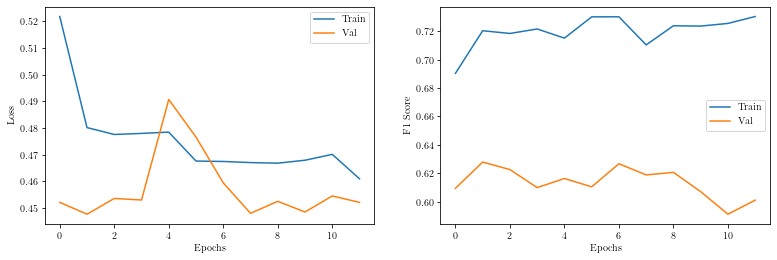

In [27]:
plt.figure(figsize=(13,4))

plt.subplot(1,2,1)
plt.plot(fit.history['loss'], label='$\mathrm{Train}$')
plt.plot(fit.history['val_loss'], label='$\mathrm{Val}$')
plt.xlabel('$\mathrm{Epochs}$')
plt.ylabel('$\mathrm{Loss}$')
plt.legend()

plt.subplot(1,2,2)
plt.plot(fit.history['f1_score'], label='$\mathrm{Train}$')
plt.plot(fit.history['val_f1_score'], label='$\mathrm{Val}$')
plt.xlabel('$\mathrm{Epochs}$')
plt.ylabel('$\mathrm{F1\ Score}$')
plt.legend()

plt.show()

In [28]:
y_pred = model.predict(x_valid_prep)
precision, recall, thresholds = precision_recall_curve(y_valid_prep, y_pred)
f1 = 2*precision*recall/(precision + recall)
thresh = thresholds[np.nanargmax(f1)]
y_pred = (y_pred > thresh).astype(int)
print(classification_report(y_valid_prep, y_pred))

45/45 [==============================] - 0s 1ms/step
              precision    recall  f1-score   support

           0       0.88      0.82      0.85      1030
           1       0.59      0.71      0.64       379

    accuracy                           0.79      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.79      0.79      1409



The model performed better since it increased F1 score significantly. The recall was retained, while the increase of precision percentage carried the F1 score. The model is now being careful in tagging non-churners incorrectly.

## VI. Class Weights instead of SMOTE

While SMOTE balances class distributions by generating synthetic samples of the churners, class weighting addresses imbalance within the loss function itself. Instead of modifying the dataset, class weights penalize misclassification of churn instances more heavily during training, guiding the model to pay more attention to them without altering the data.

In [29]:
class_weights = class_weight.compute_class_weight(class_weight = 'balanced',
                                                  classes = np.unique(y_train_prep),
                                                  y = y_train_prep)

class_weights = dict(enumerate(class_weights))

early_stopping = EarlyStopping(
    monitor = 'val_f1_score',
    mode = 'max',
    min_delta = 0.001,
    patience = 10,
    restore_best_weights = True
)

model = keras.Sequential([
    layers.Dense(32, activation = 'relu', input_shape = [x_train_prep.shape[1]]),
    layers.Dropout(rate = 0.3),
    layers.BatchNormalization(),
    layers.Dense(1, activation = 'sigmoid')
    ])

model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = [tfa.metrics.F1Score(num_classes = 1, threshold = 0.5)]
)

fit = model.fit(x_train_prep, y_train_prep,
                validation_data = (x_valid_prep, y_valid_prep),
                batch_size = 32,
                epochs = 50,
                callbacks = [early_stopping],
                class_weight = class_weights,
                verbose = 1)

Epoch 1/50
133/133 [==============================] - 1s 3ms/step - loss: 0.6231 - f1_score: 0.5273 - val_loss: 0.5245 - val_f1_score: 0.6132
Epoch 2/50
133/133 [==============================] - 0s 2ms/step - loss: 0.5612 - f1_score: 0.5825 - val_loss: 0.5130 - val_f1_score: 0.6139
Epoch 3/50
133/133 [==============================] - 0s 2ms/step - loss: 0.5498 - f1_score: 0.5939 - val_loss: 0.4958 - val_f1_score: 0.6199
Epoch 4/50
133/133 [==============================] - 0s 2ms/step - loss: 0.5184 - f1_score: 0.6119 - val_loss: 0.4947 - val_f1_score: 0.6274
Epoch 5/50
133/133 [==============================] - 0s 2ms/step - loss: 0.5179 - f1_score: 0.6068 - val_loss: 0.5063 - val_f1_score: 0.6222
Epoch 6/50
133/133 [==============================] - 0s 2ms/step - loss: 0.5137 - f1_score: 0.6062 - val_loss: 0.5151 - val_f1_score: 0.6231
Epoch 7/50
133/133 [==============================] - 0s 2ms/step - loss: 0.5051 - f1_score: 0.6174 - val_loss: 0.4986 - val_f1_score: 0.6226
Epoch 

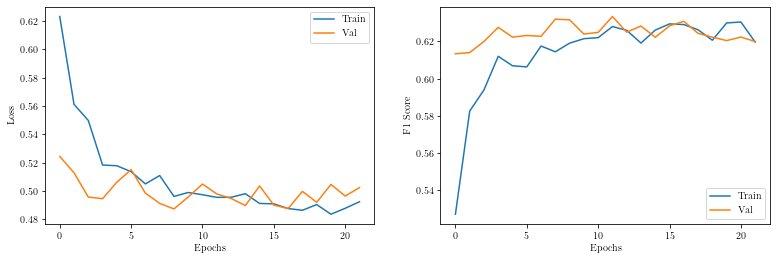

In [30]:
plt.figure(figsize=(13,4))

plt.subplot(1,2,1)
plt.plot(fit.history['loss'], label='$\mathrm{Train}$')
plt.plot(fit.history['val_loss'], label='$\mathrm{Val}$')
plt.xlabel('$\mathrm{Epochs}$')
plt.ylabel('$\mathrm{Loss}$')
plt.legend()

plt.subplot(1,2,2)
plt.plot(fit.history['f1_score'], label='$\mathrm{Train}$')
plt.plot(fit.history['val_f1_score'], label='$\mathrm{Val}$')
plt.xlabel('$\mathrm{Epochs}$')
plt.ylabel('$\mathrm{F1\ Score}$')
plt.legend()

plt.show()

In [31]:
y_pred = model.predict(x_valid_prep)
precision, recall, thresholds = precision_recall_curve(y_valid_prep, y_pred)
f1 = 2*precision*recall/(precision + recall)
thresh = thresholds[np.nanargmax(f1)]
y_pred = (y_pred > thresh).astype(int)
print(classification_report(y_valid_prep, y_pred))

45/45 [==============================] - 0s 1ms/step
              precision    recall  f1-score   support

           0       0.88      0.81      0.85      1030
           1       0.58      0.71      0.64       379

    accuracy                           0.78      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.78      0.79      1409



We have produced a result comparable to SMOTE + Learning Rate Decay by simply switching to class weighting. More non-churners are being tagged as churners, as shown by the lower precision for churners.

## VII. Class Weights + Regularization

We use L2 (ridge) regularization again.

In [32]:
class_weights = class_weight.compute_class_weight(class_weight = 'balanced',
                                                  classes = np.unique(y_train_prep),
                                                  y = y_train_prep)

class_weights = dict(enumerate(class_weights))

early_stopping = EarlyStopping(
    monitor = 'val_f1_score',
    mode = 'max',
    min_delta = 0.001,
    patience = 10,
    restore_best_weights = True
)

model = keras.Sequential([
    layers.Dense(32, activation = 'relu', input_shape = [x_train_prep.shape[1]], kernel_regularizer = l2(0.001)),
    layers.Dropout(rate = 0.3),
    layers.BatchNormalization(),
    layers.Dense(1, activation = 'sigmoid')
    ])

model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = [tfa.metrics.F1Score(num_classes = 1, threshold = 0.5)]
)

fit = model.fit(x_train_prep, y_train_prep,
                validation_data = (x_valid_prep, y_valid_prep),
                batch_size = 32,
                epochs = 50,
                callbacks = [early_stopping],
                class_weight = class_weights,
                verbose = 1)

Epoch 1/50
133/133 [==============================] - 1s 3ms/step - loss: 0.6700 - f1_score: 0.5118 - val_loss: 0.5636 - val_f1_score: 0.6126
Epoch 2/50
133/133 [==============================] - 0s 2ms/step - loss: 0.5932 - f1_score: 0.5902 - val_loss: 0.5377 - val_f1_score: 0.6179
Epoch 3/50
133/133 [==============================] - 0s 2ms/step - loss: 0.5649 - f1_score: 0.5974 - val_loss: 0.5125 - val_f1_score: 0.6207
Epoch 4/50
133/133 [==============================] - 0s 2ms/step - loss: 0.5469 - f1_score: 0.6087 - val_loss: 0.5285 - val_f1_score: 0.6109
Epoch 5/50
133/133 [==============================] - 0s 2ms/step - loss: 0.5437 - f1_score: 0.6046 - val_loss: 0.5135 - val_f1_score: 0.6278
Epoch 6/50
133/133 [==============================] - 0s 2ms/step - loss: 0.5404 - f1_score: 0.6082 - val_loss: 0.5309 - val_f1_score: 0.6132
Epoch 7/50
133/133 [==============================] - 0s 2ms/step - loss: 0.5323 - f1_score: 0.6129 - val_loss: 0.5290 - val_f1_score: 0.6154
Epoch 

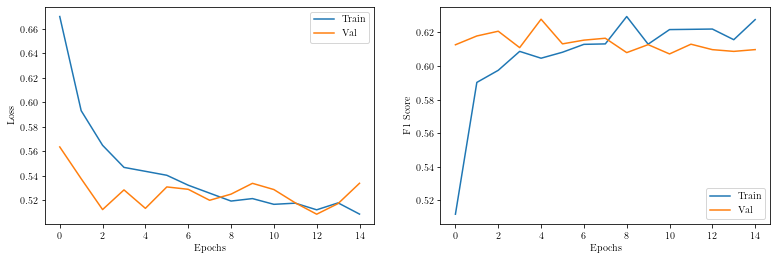

In [33]:
plt.figure(figsize=(13,4))

plt.subplot(1,2,1)
plt.plot(fit.history['loss'], label='$\mathrm{Train}$')
plt.plot(fit.history['val_loss'], label='$\mathrm{Val}$')
plt.xlabel('$\mathrm{Epochs}$')
plt.ylabel('$\mathrm{Loss}$')
plt.legend()

plt.subplot(1,2,2)
plt.plot(fit.history['f1_score'], label='$\mathrm{Train}$')
plt.plot(fit.history['val_f1_score'], label='$\mathrm{Val}$')
plt.xlabel('$\mathrm{Epochs}$')
plt.ylabel('$\mathrm{F1\ Score}$')
plt.legend()

plt.show()

In [34]:
y_pred = model.predict(x_valid_prep)
precision, recall, thresholds = precision_recall_curve(y_valid_prep, y_pred)
f1 = 2*precision*recall/(precision + recall)
thresh = thresholds[np.nanargmax(f1)]
y_pred = (y_pred > thresh).astype(int)
print(classification_report(y_valid_prep, y_pred))

45/45 [==============================] - 0s 1ms/step
              precision    recall  f1-score   support

           0       0.89      0.77      0.83      1030
           1       0.54      0.75      0.63       379

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



C:\Users\PC\AppData\Local\Temp/ipykernel_2324/1123782332.py:3: RuntimeWarning: invalid value encountered in divide
  f1 = 2*precision*recall/(precision + recall)


The recall increased dramatically, but the precision compensated for it. The F1 score was retained.

# VIII. Class Weights + Learning Rate Decay

We try to refine the pure class weighting results with learning rate decay, with the hopes of improving the F1 Score dramatically, similar to what happened to SMOTE.

In [35]:
class_weights = class_weight.compute_class_weight(class_weight = 'balanced',
                                                  classes = np.unique(y_train_prep),
                                                  y = y_train_prep)

class_weights = dict(enumerate(class_weights))

lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate = 0.001,
    decay_steps = 1000,
    decay_rate = 0.96,
    staircase = True
)
optimizer = keras.optimizers.Adam(learning_rate = lr_schedule)

early_stopping = EarlyStopping(
    monitor = 'val_f1_score',
    mode = 'max',
    min_delta = 0.001,
    patience = 10,
    restore_best_weights = True
)

model = keras.Sequential([
    layers.Dense(32, activation = 'relu', input_shape = [x_train_prep.shape[1]]),
    layers.Dropout(rate = 0.3),
    layers.BatchNormalization(),
    layers.Dense(1, activation = 'sigmoid')
    ])

model.compile(
    optimizer = optimizer,
    loss = 'binary_crossentropy',
    metrics = [tfa.metrics.F1Score(num_classes = 1, threshold = 0.5)]
)

fit = model.fit(x_train_prep, y_train_prep,
                validation_data = (x_valid_prep, y_valid_prep),
                batch_size = 32,
                epochs = 50,
                callbacks = [early_stopping],
                class_weight = class_weights,
                verbose = 1)

Epoch 1/50
133/133 [==============================] - 1s 3ms/step - loss: 0.6240 - f1_score: 0.5210 - val_loss: 0.5415 - val_f1_score: 0.5994
Epoch 2/50
133/133 [==============================] - 0s 2ms/step - loss: 0.5421 - f1_score: 0.5835 - val_loss: 0.5075 - val_f1_score: 0.6128
Epoch 3/50
133/133 [==============================] - 0s 2ms/step - loss: 0.5321 - f1_score: 0.5907 - val_loss: 0.4885 - val_f1_score: 0.6217
Epoch 4/50
133/133 [==============================] - 0s 2ms/step - loss: 0.5265 - f1_score: 0.6008 - val_loss: 0.5017 - val_f1_score: 0.6180
Epoch 5/50
133/133 [==============================] - 0s 2ms/step - loss: 0.5149 - f1_score: 0.6087 - val_loss: 0.4993 - val_f1_score: 0.6185
Epoch 6/50
133/133 [==============================] - 0s 2ms/step - loss: 0.5103 - f1_score: 0.6098 - val_loss: 0.5069 - val_f1_score: 0.6139
Epoch 7/50
133/133 [==============================] - 0s 2ms/step - loss: 0.5007 - f1_score: 0.6187 - val_loss: 0.5091 - val_f1_score: 0.6135
Epoch 

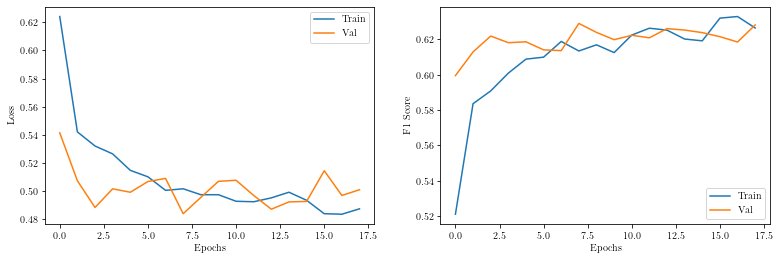

In [36]:
plt.figure(figsize=(13,4))

plt.subplot(1,2,1)
plt.plot(fit.history['loss'], label='$\mathrm{Train}$')
plt.plot(fit.history['val_loss'], label='$\mathrm{Val}$')
plt.xlabel('$\mathrm{Epochs}$')
plt.ylabel('$\mathrm{Loss}$')
plt.legend()

plt.subplot(1,2,2)
plt.plot(fit.history['f1_score'], label='$\mathrm{Train}$')
plt.plot(fit.history['val_f1_score'], label='$\mathrm{Val}$')
plt.xlabel('$\mathrm{Epochs}$')
plt.ylabel('$\mathrm{F1\ Score}$')
plt.legend()

plt.show()

In [37]:
y_pred = model.predict(x_valid_prep)
precision, recall, thresholds = precision_recall_curve(y_valid_prep, y_pred)
f1 = 2*precision*recall/(precision + recall)
thresh = thresholds[np.nanargmax(f1)]
y_pred = (y_pred > thresh).astype(int)
print(classification_report(y_valid_prep, y_pred))

45/45 [==============================] - 0s 1ms/step
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1030
           1       0.52      0.79      0.63       379

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



The aggressiveness of the model in finding churners was increased. We experiment with combining learning rate decay and regularization.

# IX. Class Weights + Learning Rate Decay + L2 Regularization

In [38]:
class_weights = class_weight.compute_class_weight(class_weight = 'balanced',
                                                  classes = np.unique(y_train_prep),
                                                  y = y_train_prep)

class_weights = dict(enumerate(class_weights))

lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate = 0.001,
    decay_steps = 1000,
    decay_rate = 0.96,
    staircase = True
)
optimizer = keras.optimizers.Adam(learning_rate = lr_schedule)

early_stopping = EarlyStopping(
    monitor = 'val_f1_score',
    mode = 'max',
    min_delta = 0.001,
    patience = 10,
    restore_best_weights = True
)

model = keras.Sequential([
    layers.Dense(32, activation = 'relu', input_shape = [x_train_prep.shape[1]], kernel_regularizer = l2(0.001)),
    layers.Dropout(rate = 0.3),
    layers.BatchNormalization(),
    layers.Dense(1, activation = 'sigmoid')
    ])

model.compile(
    optimizer = optimizer,
    loss = 'binary_crossentropy',
    metrics = [tfa.metrics.F1Score(num_classes = 1, threshold = 0.5)]
)

fit = model.fit(x_train_prep, y_train_prep,
                validation_data = (x_valid_prep, y_valid_prep),
                batch_size = 32,
                epochs = 50,
                callbacks = [early_stopping],
                class_weight = class_weights,
                verbose = 1)

Epoch 1/50
133/133 [==============================] - 1s 3ms/step - loss: 0.6775 - f1_score: 0.5151 - val_loss: 0.5411 - val_f1_score: 0.6199
Epoch 2/50
133/133 [==============================] - 0s 2ms/step - loss: 0.5923 - f1_score: 0.5852 - val_loss: 0.5515 - val_f1_score: 0.6186
Epoch 3/50
133/133 [==============================] - 0s 2ms/step - loss: 0.5698 - f1_score: 0.5941 - val_loss: 0.5333 - val_f1_score: 0.6266
Epoch 4/50
133/133 [==============================] - 0s 2ms/step - loss: 0.5612 - f1_score: 0.5989 - val_loss: 0.5361 - val_f1_score: 0.6190
Epoch 5/50
133/133 [==============================] - 0s 2ms/step - loss: 0.5500 - f1_score: 0.6059 - val_loss: 0.5424 - val_f1_score: 0.6157
Epoch 6/50
133/133 [==============================] - 0s 2ms/step - loss: 0.5465 - f1_score: 0.5982 - val_loss: 0.5391 - val_f1_score: 0.6044
Epoch 7/50
133/133 [==============================] - 0s 2ms/step - loss: 0.5337 - f1_score: 0.6192 - val_loss: 0.5437 - val_f1_score: 0.6025
Epoch 

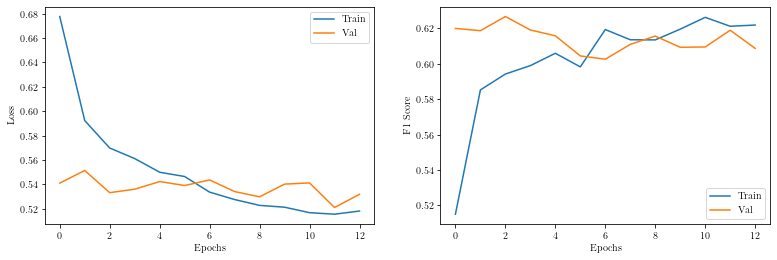

In [39]:
plt.figure(figsize=(13,4))

plt.subplot(1,2,1)
plt.plot(fit.history['loss'], label='$\mathrm{Train}$')
plt.plot(fit.history['val_loss'], label='$\mathrm{Val}$')
plt.xlabel('$\mathrm{Epochs}$')
plt.ylabel('$\mathrm{Loss}$')
plt.legend()

plt.subplot(1,2,2)
plt.plot(fit.history['f1_score'], label='$\mathrm{Train}$')
plt.plot(fit.history['val_f1_score'], label='$\mathrm{Val}$')
plt.xlabel('$\mathrm{Epochs}$')
plt.ylabel('$\mathrm{F1\ Score}$')
plt.legend()

plt.show()

In [40]:
y_pred = model.predict(x_valid_prep)
precision, recall, thresholds = precision_recall_curve(y_valid_prep, y_pred)
f1 = 2*precision*recall/(precision + recall)
thresh = thresholds[np.nanargmax(f1)]
y_pred = (y_pred > thresh).astype(int)
print(classification_report(y_valid_prep, y_pred))

45/45 [==============================] - 0s 774us/step
              precision    recall  f1-score   support

           0       0.87      0.84      0.85      1030
           1       0.60      0.66      0.63       379

    accuracy                           0.79      1409
   macro avg       0.74      0.75      0.74      1409
weighted avg       0.80      0.79      0.79      1409



The model was prone to underfitting, stemming from dropout and regularization, the combination of which may be an overkill. However, the balance between precision and recall is almost perfect. The problem is we care about recall more, as we will discuss later.

## X. Model deployment

It seems like we have reached the ceiling of this architecture. Further hyperparameter tuning will not lead to appreciable improvement given the data and neural network architecture. We thus deploy the best model we have, where the F1 score and recall are the highest since we care more about the customers who will most likely leave. This model is the Class Weights + Learning Rate Decay model.

In [41]:
class_weights = class_weight.compute_class_weight(class_weight = 'balanced',
                                                  classes = np.unique(y_train_prep),
                                                  y = y_train_prep)

class_weights = dict(enumerate(class_weights))

lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate = 0.001,
    decay_steps = 1000,
    decay_rate = 0.96,
    staircase = True
)
optimizer = keras.optimizers.Adam(learning_rate = lr_schedule)

early_stopping = EarlyStopping(
    monitor = 'val_f1_score',
    mode = 'max',
    min_delta = 0.001,
    patience = 10,
    restore_best_weights = True
)

model = keras.Sequential([
    layers.Dense(32, activation = 'relu', input_shape = [x_train_prep.shape[1]]),
    layers.Dropout(rate = 0.3),
    layers.BatchNormalization(),
    layers.Dense(1, activation = 'sigmoid')
    ])

model.compile(
    optimizer = optimizer,
    loss = 'binary_crossentropy',
    metrics = [tfa.metrics.F1Score(num_classes = 1, threshold = 0.5)]
)

fit = model.fit(x_train_prep, y_train_prep,
                validation_data = (x_valid_prep, y_valid_prep),
                batch_size = 32,
                epochs = 50,
                callbacks = [early_stopping],
                class_weight = class_weights,
                verbose = 1)

Epoch 1/50
133/133 [==============================] - 1s 3ms/step - loss: 0.6321 - f1_score: 0.5251 - val_loss: 0.5440 - val_f1_score: 0.5954
Epoch 2/50
133/133 [==============================] - 0s 2ms/step - loss: 0.5494 - f1_score: 0.5846 - val_loss: 0.5132 - val_f1_score: 0.6144
Epoch 3/50
133/133 [==============================] - 0s 2ms/step - loss: 0.5421 - f1_score: 0.5984 - val_loss: 0.5041 - val_f1_score: 0.6216
Epoch 4/50
133/133 [==============================] - 0s 2ms/step - loss: 0.5254 - f1_score: 0.6001 - val_loss: 0.4942 - val_f1_score: 0.6207
Epoch 5/50
133/133 [==============================] - 0s 2ms/step - loss: 0.5156 - f1_score: 0.6078 - val_loss: 0.4982 - val_f1_score: 0.6197
Epoch 6/50
133/133 [==============================] - 0s 2ms/step - loss: 0.5108 - f1_score: 0.6054 - val_loss: 0.5030 - val_f1_score: 0.6183
Epoch 7/50
133/133 [==============================] - 0s 2ms/step - loss: 0.5078 - f1_score: 0.6164 - val_loss: 0.4934 - val_f1_score: 0.6247
Epoch 

We now use the test data for the final report.

In [42]:
y_pred = model.predict(x_test_prep)

precision, recall, thresholds = precision_recall_curve(y_test_prep, y_pred)
f1 = 2*precision*recall/(precision + recall)
thresh = thresholds[np.nanargmax(f1)]

y_pred = (y_pred > thresh).astype(int)

45/45 [==============================] - 0s 2ms/step


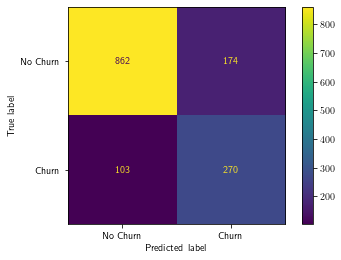

In [43]:
ConfusionMatrixDisplay(confusion_matrix(y_test_prep,y_pred), display_labels= ['No Churn', 'Churn']).plot()
plt.show()

The confusion matrix displays the following values:
- **True Negatives**: The model correctly identified 862 non-churners.
- **False Positives**: The model misidentified 174 non-churners as churners.
- **False Negatives**: The model misidentified 103 churners as non-churners.
- **True Positives**: The model correctly identified 270 churners.

It will be more illuminating to turn into proportions of true values and predictions, given that our data is highly imbalanced. 

In [44]:
print(classification_report(y_test_prep, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.83      0.86      1036
           1       0.61      0.72      0.66       373

    accuracy                           0.80      1409
   macro avg       0.75      0.78      0.76      1409
weighted avg       0.82      0.80      0.81      1409



Out of all the predicted churners (444), 61% of them turned out to be actual churners (precision), and out of all the true churners (373), 72% were predicted correctly (recall). The model was made to be aggressive in finding churners, such that non-churners are being tagged incorrectly. An important question that was left unaddressed is, why do we maximize the F1 score instead of the recall? The answer is, precision still matters. A customer falsely flagged as churn may indicate that this customer is at risk of churning. The company might want to mitigate this risk by offering a promo to increase the likelihood of retention. This will also cost the company. While tagging customers as `Churn` aggressively might prevent financial loss, money might leak on promos instead. We have to strike a balance between the two.